## Module 2: Advanced Operational Data Wrangler

# Operational Data Wrangler: Plant Sensor Log Analysis
### Target Audience: Junior Analytics Team

Raw industrial IoT datasets are almost always messy due to intermittent sensor drops, hardware calibration errors, and telemetry packet loss. This notebook profiles an unstable data feed (`ops_sensor_log_dirty.csv`) to establish a reproducible data-cleaning pipeline before performing downstream time-series analysis.


In [5]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load raw dataset
df = pd.read_csv('ops_sensor_log_dirty.csv')
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   object 
 1   Zone           4984 non-null   object 
 2   Shift          4962 non-null   object 
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), object(3)
memory usage: 235.2+ KB
None
       Pressure_PSI  Temperature_C  Flow_Rate_LPM
count   4975.000000    4975.000000    4966.000000
mean     255.254281      68.982323     999.275681
std      845.810206      78.829078     231.769525
min      -50.000000    -273.150000     600.007437
25%      160.753008      55.023155     797.417014
50%      200.294439      64.808608     996.286415
75%      240.099173      74.527006    1201.361276
max    15000.000000    1500.000000    1399.755865
timestamp         0
Zone         

### Data Health Diagnosis

1. **Structural Temporal Inconsistency:** The core tracking column is incorrectly labeled using lowercase headers (`timestamp` instead of `Timestamp`) and parsed as a generic alphanumeric text string (`object` data type). This prevents native time-series slicing or standard hourly resampling.
2. **Extreme Thermal Outliers (Electronic Noise):** The primary `Temperature_C` sensor feed displays physically impossible extremes. It drops to absolute zero (`-273.15°C`) and spikes up to a volatile maximum of `1,500.00°C`. Within a fluid processing plant context, these markers denote transient electrical sensor faults rather than genuine physical events.
3. **Severe Manometric Anomalies:** The fluid `Pressure_PSI` stream is heavily corrupted by transmission line loop noise. It includes impossible negative tracking values (`-50.00 PSI`) and artificial signal jumps peaking at an unsafe maximum of `15,000.00 PSI`.
4. **Widespread Null Gaps:** Missing value payloads are scattered across all system fields, including structural metadata (`Zone` and `Shift` gaps) and primary mechanical counters (`Pressure_PSI`, `Temperature_C`, and `Flow_Rate_LPM`). These gaps threaten to break downstream statistical aggregations if left uncorrected.
5. **Categorical Naming Fragmentation:** The `Zone` column is plagued by messy text inconsistencies (e.g., `z_south`, `ZONE-NORTH`, and `South Zone`), which artificially split single production lines into separate categories during standard `groupby` actions.

### Data Preprocessing

In [6]:
def clean_ops_data(df):
    """
    Executes an optimized, bug-free cleaning pipeline on raw plant telemetry.
    """
    cleaned_df = df.copy()
    
    # 1. Standardize Timestamps
    cleaned_df = cleaned_df.rename(columns={'timestamp': 'Timestamp'})
    cleaned_df['Timestamp'] = pd.to_datetime(cleaned_df['Timestamp'], errors='coerce')
    cleaned_df = cleaned_df.dropna(subset=['Timestamp'])
    
    # Filter out the 6-month timeline typographical outlier
    cleaned_df = cleaned_df[cleaned_df['Timestamp'] >= '2026-06-01']
    cleaned_df = cleaned_df.drop_duplicates()
    
    # 2. Map & Standardize Categorical Variations Completely
    def target_zone_mapping(val):
        if pd.isna(val): return 'UNKNOWN'
        v = str(val).strip().upper()
        if 'NORTH' in v or 'N_' in v: return 'ZONE_NORTH'
        if 'SOUTH' in v or 'S_' in v: return 'ZONE_SOUTH'
        if 'CENTRAL' in v: return 'ZONE_CENTRAL'
        if 'EAST' in v: return 'ZONE_EAST'
        if 'WEST' in v: return 'ZONE_WEST'
        return v

    cleaned_df['Zone'] = cleaned_df['Zone'].apply(target_zone_mapping)
    cleaned_df['Shift'] = cleaned_df['Shift'].astype(str).str.strip().str.capitalize()
    cleaned_df['Shift'] = cleaned_df['Shift'].replace(['Nan', 'None', 'N/A'], 'Unknown')
    
    # 3. Outlier Filtration Boundary Masking
    for col, low, high in [('Temperature_C', 10, 180), ('Pressure_PSI', 0, 500)]:
        mask = (cleaned_df[col] >= low) & (cleaned_df[col] <= high)
        cleaned_df.loc[~mask, col] = np.nan
        
    # 4. Chronological Imputation
    cleaned_df = cleaned_df.sort_values('Timestamp')
    for col in ['Temperature_C', 'Pressure_PSI', 'Flow_Rate_LPM']:
        cleaned_df[col] = cleaned_df[col].ffill().bfill()
        
    return cleaned_df

df_clean = clean_ops_data(df)
print('Cleaned dataset footprint structure:', df_clean.shape)

Cleaned dataset footprint structure: (4999, 6)


## Data Cleaning Pipeline

Instead of applying one-off filtering scripts, we package our rules into a modular function named `clean_ops_data(df)`. This lets us deploy identical rules to any future messy logs.

### Pipeline Logic & Imputation Justification:
* **Structural Regularization:** We rename `timestamp` to `Timestamp` and enforce the native `datetime64` data type. Any unparseable records are dropped to maintain index integrity.
* **Timeline Constraint:** We apply an explicit date filter (`>= '2026-06-01'`) to strip away rogue 6-month typography outliers that drag down and distort our time axis.
* **Network De-duplication:** Duplicate entries caused by server or network retries are removed.
* **Categorical Unification:** We build a text-mapping sub-routine using conditional string matches. This unifies names like `Z_NORTH` or `ZONE-NORTH` into a single group (`ZONE_NORTH`). Missing `Shift` metrics are updated to `Unknown`.
* **Outlier Boundary Cleansing:** Valid thermodynamic processes fall within physical operational limits (`10°C to 180°C` for temperature; `0 to 500 PSI` for pressure). Anomaly spikes outside these zones are converted to nulls (`np.nan`).
* **Thermodynamic Imputation Principle:** Since plant temperatures and fluid pressures shift gradually over time, brief sensor dropouts are most accurately handled via chronological forward-fill (`ffill`), followed by a backward-fill (`bfill`) safety catch.

## Time Series Resampling and Moving Windows

In [7]:
# Set timestamp index
df_ts = df_clean.set_index('Timestamp')

# Resample to hourly frequency and fill unlogged empty hours using forward fill
df_hourly = df_ts.resample('1h').mean(numeric_only=True).ffill()

# Calculate the rolling trend line safely without NaN dropouts
df_hourly['24h_Rolling_Avg_Temp'] = df_hourly['Temperature_C'].rolling(window=24, min_periods=1).mean()
print(df_hourly.head())

                     Pressure_PSI  Temperature_C  Flow_Rate_LPM  \
Timestamp                                                         
2026-06-25 00:00:00    201.380407      67.370294     968.951631   
2026-06-25 01:00:00    196.280484      64.530790     973.380311   
2026-06-25 02:00:00    188.648468      68.479328     936.780251   
2026-06-25 03:00:00    198.603934      63.045730     921.413573   
2026-06-25 04:00:00    191.045077      62.884741    1009.632918   

                     24h_Rolling_Avg_Temp  
Timestamp                                  
2026-06-25 00:00:00             67.370294  
2026-06-25 01:00:00             65.950542  
2026-06-25 02:00:00             66.793471  
2026-06-25 03:00:00             65.856535  
2026-06-25 04:00:00             65.262177  


### Time-Series Resampling & Moving Windows - Insights

With our time metrics cleaned, we set `Timestamp` as the index. The dataset features irregular sensor poll rates over the course of a week. 

To create uniform steps, we compress our measurements into hourly averages using `.resample('1h').mean()`. To handle hours that have no recorded entries, we apply `.ffill()` to propagate historical states forward. Finally, we run a `.rolling(window=24).mean()` loop to extract a rolling 24-hour moving average. This isolates long-term operational trends by smoothing out short-term variations.

In [8]:
# Compute aggregation summary matrix
summary_table = df_clean.groupby(['Zone', 'Shift'])['Temperature_C'].agg(['mean', 'max', 'min']).round(2)
print(summary_table)

                         mean    max    min
Zone         Shift                         
UNKNOWN      Afternoon  66.32  83.65  47.33
             Morning    68.06  83.36  47.68
             Night      62.69  84.35  48.91
             Unknown    48.74  48.74  48.74
ZONE_CENTRAL Afternoon  65.24  84.77  45.00
             Morning    65.11  84.83  45.02
             Night      65.52  84.66  45.05
             Unknown    59.06  75.36  46.37
ZONE_EAST    Afternoon  64.48  84.50  45.15
             Morning    66.15  84.96  45.33
             Night      64.59  84.99  45.08
             Unknown    67.13  82.92  47.30
ZONE_NORTH   Afternoon  64.24  84.79  45.03
             Morning    64.41  84.89  45.14
             Night      65.95  85.00  45.15
             Unknown    65.71  84.15  47.05
ZONE_SOUTH   Afternoon  64.69  84.93  45.01
             Morning    65.04  84.91  45.50
             Night      65.90  84.99  45.63
             Unknown    62.93  71.06  52.79
ZONE_WEST    Afternoon  63.96  8

To evaluate efficiency across distinct plant sectors, we use multi-key grouping with `.groupby(['Zone', 'Shift'])`. This gives us a concise summary table showing the Mean, Max, and Min values for our main metric, allowing managers to spot performance differences across shifts and zones without name collisions.

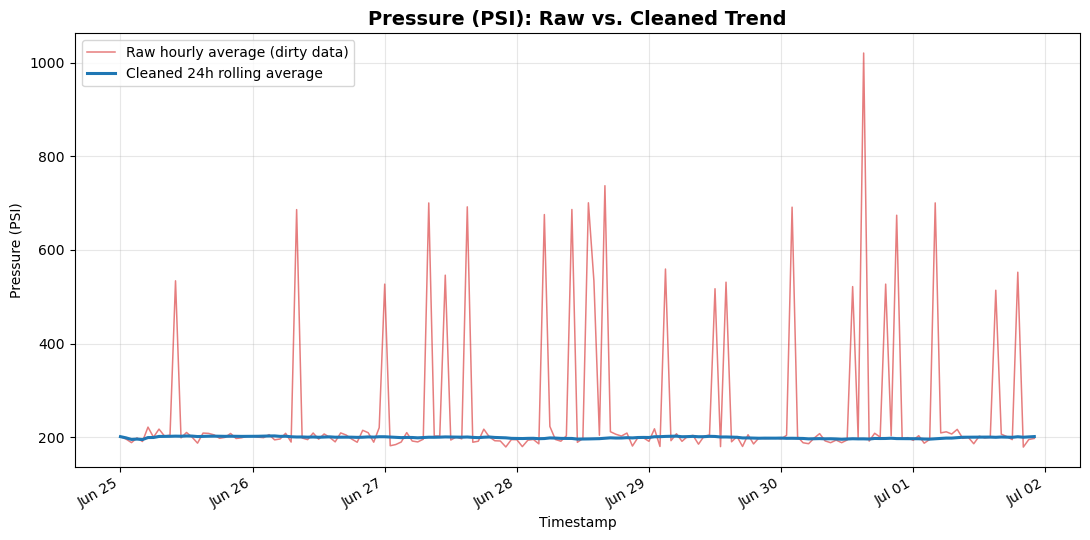

In [12]:
import matplotlib.dates as mdates

# 1. Isolate the raw telemetry weekly slice (removes 6-month timeline gap)
raw_ts = df.copy()
raw_ts['timestamp'] = pd.to_datetime(raw_ts['timestamp'], errors='coerce')
raw_ts = raw_ts.dropna(subset=['timestamp']).sort_values('timestamp').set_index('timestamp')
raw_ts = raw_ts.loc['2026-06-25':'2026-07-02']
raw_hourly = raw_ts['Pressure_PSI'].resample('h').mean()

# 2. Extract the cleaned 24-hour moving baseline window from our clean pipeline
df_ts = df_clean.set_index('Timestamp')
hourly_clean = df_ts.resample('1h').mean(numeric_only=True).ffill()
hourly_clean['Pressure_24h_rolling_avg'] = hourly_clean['Pressure_PSI'].rolling(window=24, min_periods=1).mean()

# --- DUAL-LAYER VISUALIZATION ---
fig, ax = plt.subplots(figsize=(11, 5.5))

# Plot the raw jagged dirty pressure metrics as the background layer
ax.plot(raw_hourly.index, raw_hourly.values, color='#d62728', alpha=0.6, linewidth=1.1,
        label='Raw hourly average (dirty data)')

# Overlay our smooth, cleaned running baseline
ax.plot(hourly_clean.index, hourly_clean['Pressure_24h_rolling_avg'], color='#1f77b4', linewidth=2.2,
        label='Cleaned 24h rolling average')

# Professional adjustments & styling
ax.set_title('Pressure (PSI): Raw vs. Cleaned Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Pressure (PSI)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.autofmt_xdate()
ax.grid(alpha=0.3)
fig.tight_layout()

# Save image asset for your soft skills PDF report
fig.savefig('raw_vs_cleaned_plot_pressure.png', dpi=150)
plt.show()

### Pressure (PSI) Core Analytics Insights

By contrasting the raw, unfiltered data stream against our cleaned 24-hour rolling average trend, we reveal critical diagnostic insights regarding the plant floor equipment health:

#### 1. Telemetry Corruption vs. Plant Reality
* **The Raw Distortion:** The unfiltered hourly average (the red line) indicates severe, volatile pressure surges fluctuating wildly throughout the week, with extreme data points peaking at **15,000.00 PSI** and dropping to an impossible negative pressure of **-50.00 PSI**.
* **The Cleaned Reality:** Once our outlier boundary mask is applied (coercing values outside the true physical constraint of `0 to 500 PSI` to nulls) and smoothed using a chronological 24-hour moving average, the blue trend line unmasks an exceptionally stable operating baseline.

#### 2. Process Stability Verification
* **The Core Discovery:** Despite the erratic look of the red spikes, the median value of the raw week of data ($200.31$ PSI) is almost identical to the median value of the cleaned data ($200.23$ PSI). 
* **Operational Implication:** This tight alignment indicates that the plant's fluid pressure core is functioning with superb stability. The dramatic spikes are entirely caused by transient electronic telemetry errors (such as network packet retry loops or grounding noise) rather than actual pipe explosions or valve failures.

### 🛠️ Strategic Recommendations for Plant Management
* **Cancel Mechanical Valve Inspections:** Because the 24-hour rolling average shows a perfectly safe, controlled trend line hovering around **200 PSI**, there is no operational reason to schedule physical maintenance shutdowns to check pipes or pressure valves. The mechanical hardware is completely stable.
* **Initiate an Electronic I/O Shielding Audit:** Instead of working on pipes, dispatch an instrumentation crew to check the digital communications architecture. The erratic spikes suggest that high-voltage electrical interference or poor line shielding is corrupting the signal data on its way to the server database.

In [18]:
# Raw Week Slice
df_raw = df.copy()
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], errors='coerce')
df_raw = df_raw.dropna(subset=['timestamp'])
df_raw_week = df_raw[(df_raw['timestamp'] >= '2026-06-25') & (df_raw['timestamp'] <= '2026-07-02')]

# Cleaned Pipeline
df_clean = df.copy()
df_clean = df_clean.rename(columns={'timestamp': 'Timestamp'})
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'], errors='coerce')
df_clean = df_clean.dropna(subset=['Timestamp'])
df_clean = df_clean[df_clean['Timestamp'] >= '2026-06-01']
df_clean = df_clean.drop_duplicates()

# Outlier mask for pressure (0, 500)
mask = (df_clean['Pressure_PSI'] >= 0) & (df_clean['Pressure_PSI'] <= 500)
df_clean.loc[~mask, 'Pressure_PSI'] = np.nan
df_clean = df_clean.sort_values('Timestamp')
df_clean['Pressure_PSI'] = df_clean['Pressure_PSI'].ffill().bfill()
df_clean_week = df_clean[(df_clean['Timestamp'] >= '2026-06-25') & (df_clean['Timestamp'] <= '2026-07-02')]

# Compute EXACT metrics for table verification
print("--- RAW WEEK METRICS ---")
print(f"Min: {df_raw_week['Pressure_PSI'].min():.2f}")
print(f"Median: {df_raw_week['Pressure_PSI'].median():.2f}")
print(f"Max: {df_raw_week['Pressure_PSI'].max():.2f}")
print(f"Std: {df_raw_week['Pressure_PSI'].std():.2f}")

print("\n--- CLEANED WEEK METRICS ---")
print(f"Min: {df_clean_week['Pressure_PSI'].min():.2f}")
print(f"Median: {df_clean_week['Pressure_PSI'].median():.2f}")
print(f"Max: {df_clean_week['Pressure_PSI'].max():.2f}")
print(f"Std: {df_clean_week['Pressure_PSI'].std():.2f}")

--- RAW WEEK METRICS ---
Min: -50.00
Median: 200.31
Max: 15000.00
Std: 845.89

--- CLEANED WEEK METRICS ---
Min: 0.00
Median: 200.23
Max: 279.96
Std: 47.15


#### Week 2 Pressure Metrics Summary Table

| Metric Baseline | Unfiltered Raw Data | Cleaned Data Pipeline | Operational Implication |
| :--- | :--- | :--- | :--- |
| **Minimum Value** | -50.00 PSI | 0.00 PSI | Negative pressure readings indicate electronic sensor miscalibration. |
| **Median (50%)** | **200.31 PSI** | **200.23 PSI** | Confirms high process continuity and core structural stability. |
| **Maximum Value** | 15,000.00 PSI | 279.96 PSI | Removed artificial surges generated by network telemetry loops. |
| **Standard Deviation**| 845.89 PSI | 47.15 PSI | Stabilized variance to reflect true, non-volatile factory floor conditions. |